In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

# Read the data

In [2]:
# Data option
data_option = 'withDiffusion'
f_data = f'./data_{data_option}_withSpinup.csv'
df = pd.read_csv(f_data, index_col=0)
df.index = pd.to_datetime(df.index)
df.head()

,J,SNOW,SM,P,P2,ET,Tair,SWIN,Q,C_J,C_P,C_P2,C_P2b,C_Q
2004-10-03,0.022043,0.0,0.007034,0.022043,0.029077,0.134187,282.810966,146.457372,0.123941,0.0,0.0,0.0,0.0,0.0
2004-10-04,0.149126,0.0,0.037802,0.149126,0.186927,0.136580,282.844774,148.803400,0.033198,0.0,0.0,0.0,0.0,0.0
2004-10-05,0.000000,0.0,0.021453,0.000000,0.021453,0.127766,283.343637,149.635792,0.012731,0.0,0.0,0.0,0.0,0.0
2004-10-06,0.779309,0.0,0.036492,0.779309,0.815801,0.127668,283.243045,138.892277,0.006209,0.0,0.0,0.0,0.0,0.0
2004-10-07,0.164453,0.0,0.051470,0.164453,0.215923,0.128751,283.357600,142.605490,0.003617,0.0,0.0,0.0,0.0,0.0


# Check and clean zero flow and concentrations

In [3]:
df_new = df.copy()
zero_q = df_new['Q']==0

# Correct zero flow concentration to nan
df_new.loc[zero_q, 'C_Q'] = np.nan

# Correct zero flow to very low values
Qmin = df_new.loc[~zero_q, 'Q'].min()
df_new.loc[zero_q, 'Q'] = Qmin / 2

/home/bizon/miniforge3/envs/nn-flow-transport/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


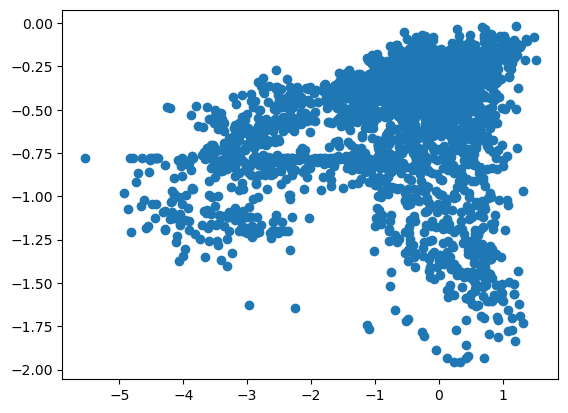

In [4]:
# plt.scatter(np.log10(df_new.loc[~zero_q, 'Q']), np.log10(df_new.loc[~zero_q, 'C_Q']))
plt.scatter(np.log10(df_new['Q']), np.log10(df_new['C_Q']))

In [5]:
# np.isnan(df_new['C_Q']).sum()

# Calculate the storage change

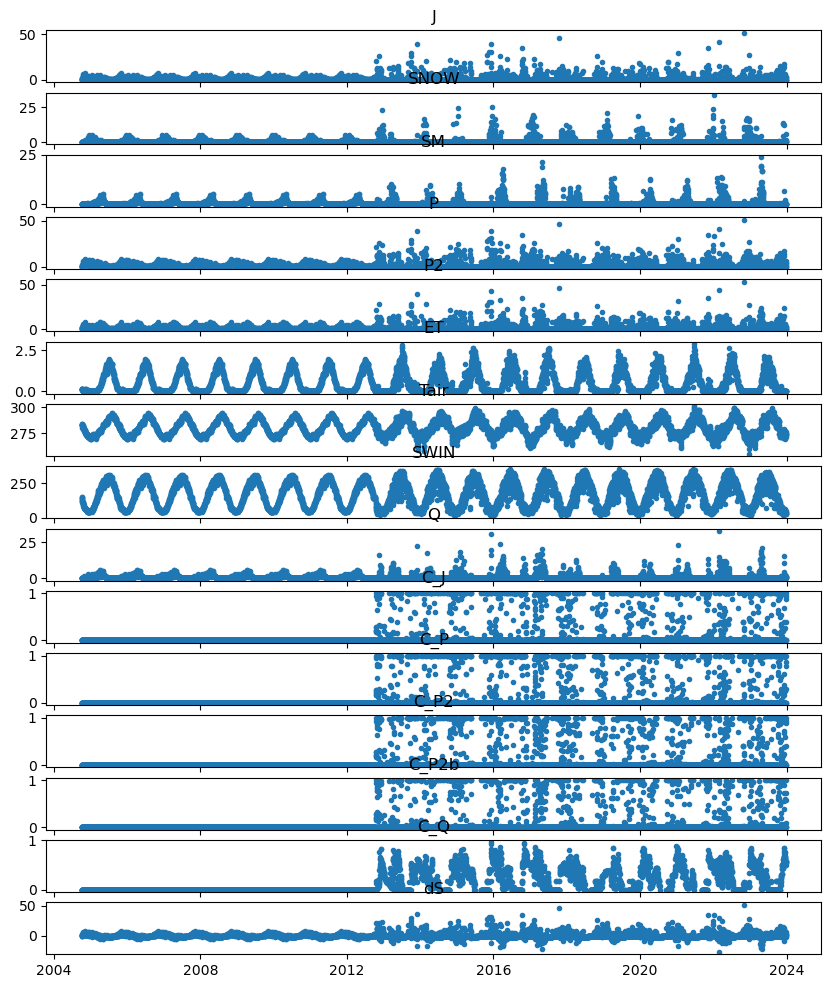

In [6]:
df_new['dS'] = df_new['P'] - df_new['ET'] - df_new['Q']
fig, axes = plt.subplots(df_new.shape[1], sharex=True, figsize=(10,12))
for i, ax in enumerate(axes):
    ax.plot(df_new.iloc[:,i], '.')
    ax.set(title=df_new.columns[i])


# Save the files

In [7]:
df_new.to_csv(f'./data_{data_option}_withSpinup-correctedZeroFlow.csv')